In [ ]:
import pandas as pd

# Load transaction data from CSV into a DataFrame
# This is the core dataset used for all analysis
df = pd.read_csv("transactions.csv")

# Display the first few rows to confirm the data loaded correctly
df.head()


,transaction_id,date,amount,merchant,category,account_id
0,1,2024-01-02,-5.20,Starbucks,Coffee,ACC001
1,2,2024-01-02,-42.50,Tesco,Groceries,ACC001
2,3,2024-01-03,-12.99,Netflix,Subscriptions,ACC001
3,4,2024-01-05,1500.00,Employer Ltd,Salary,ACC001
4,5,2024-01-06,-60.00,Shell,Fuel,ACC001


In [ ]:

# Convert the 'date' column from string to datetime format
# This allows us to extract months, sort by date, and run time‑based analysis
df['date'] = pd.to_datetime(df['date'])

# Create a 'month' column (e.g., 2024-01, 2024-02)
# Useful for grouping transactions by month
df['month'] = df['date'].dt.to_period('M')

df.head()


,transaction_id,date,amount,merchant,category,account_id,month
0,1,2024-01-02,-5.20,Starbucks,Coffee,ACC001,2024-01
1,2,2024-01-02,-42.50,Tesco,Groceries,ACC001,2024-01
2,3,2024-01-03,-12.99,Netflix,Subscriptions,ACC001,2024-01
3,4,2024-01-05,1500.00,Employer Ltd,Salary,ACC001,2024-01
4,5,2024-01-06,-60.00,Shell,Fuel,ACC001,2024-01


In [ ]:
# Monthly cashflow: income vs spending
# Calculate net cashflow per month (income minus spending)
# Positive values = more money coming in than going out
# Negative values = overspending
monthly_cashflow = df.groupby('month')['amount'].sum().reset_index()

monthly_cashflow


,month,amount
0,2024-01,1010.81
1,2024-02,982.81


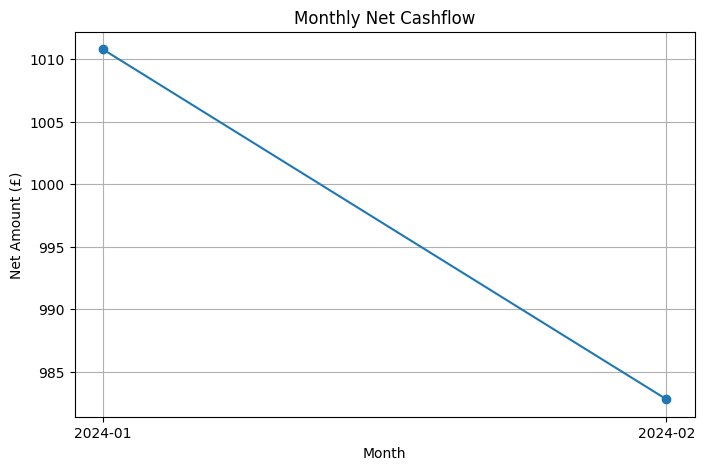

In [ ]:
import matplotlib.pyplot as plt

# Line chart showing how net cashflow changes month‑to‑month
plt.figure(figsize=(8,5))
plt.plot(monthly_cashflow['month'].astype(str), monthly_cashflow['amount'], marker='o')
plt.title("Monthly Net Cashflow")
plt.xlabel("Month")
plt.ylabel("Net Amount (£)")
plt.grid(True)
plt.show()


In [ ]:
# Filter only negative amounts (spending) and group by category
# This shows where the user spends the most money
category_spend = df[df['amount'] < 0].groupby('category')['amount'].sum().sort_values()

category_spend


category
Rent            -400.00
Utilities       -250.00
Fuel            -130.00
Groceries        -87.50
Subscriptions    -55.98
Shopping         -55.00
Food             -17.50
Coffee           -10.40
Name: amount, dtype: float64

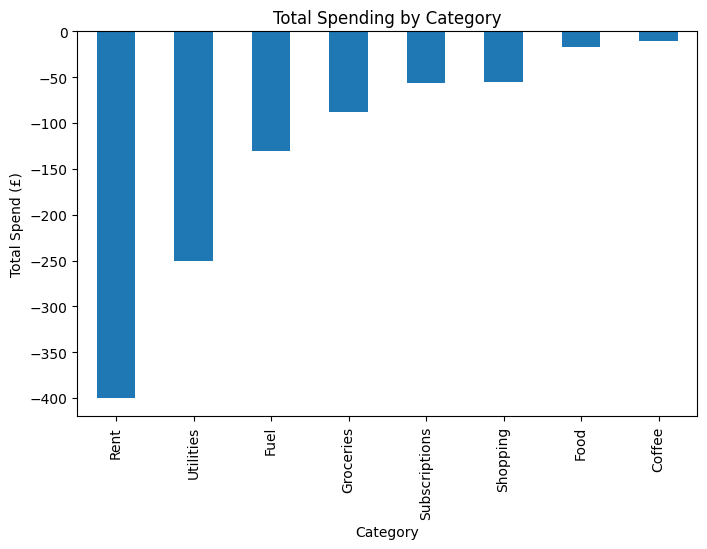

In [ ]:
# Bar chart showing total spend per category
plt.figure(figsize=(8,5))
category_spend.plot(kind='bar')
plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Spend (£)")
plt.show()


In [ ]:
# Simple anomaly detection using the 95th percentile
# Flags unusually large transactions (potential fraud or unusual behaviour)
# Detect unusually large transactions (simple rule-based anomaly detection)
threshold = df['amount'].quantile(0.95)  # top 5% of amounts
anomalies = df[df['amount'] > threshold]

anomalies


,transaction_id,date,amount,merchant,category,account_id,month


In [ ]:
# Identify subscription transactions
subscription_merchants = ['Netflix', 'Spotify', 'BT']

# Filter the dataset to only subscription transactions
subscriptions = df[df['merchant'].isin(subscription_merchants)].copy()
subscriptions


,transaction_id,date,amount,merchant,category,account_id,month
2,3,2024-01-03,-12.99,Netflix,Subscriptions,ACC001,2024-01
7,8,2024-01-15,-120.00,BT,Utilities,ACC001,2024-01
9,10,2024-01-25,-15.00,Spotify,Subscriptions,ACC001,2024-01
17,18,2024-02-15,-130.00,BT,Utilities,ACC001,2024-02
18,19,2024-02-18,-12.99,Netflix,Subscriptions,ACC001,2024-02
19,20,2024-02-25,-15.00,Spotify,Subscriptions,ACC001,2024-02


In [ ]:
# Calculate total subscription spending per month
monthly_subscriptions = subscriptions.groupby('month')['amount'].sum().reset_index()
monthly_subscriptions


,month,amount
0,2024-01,-147.99
1,2024-02,-157.99


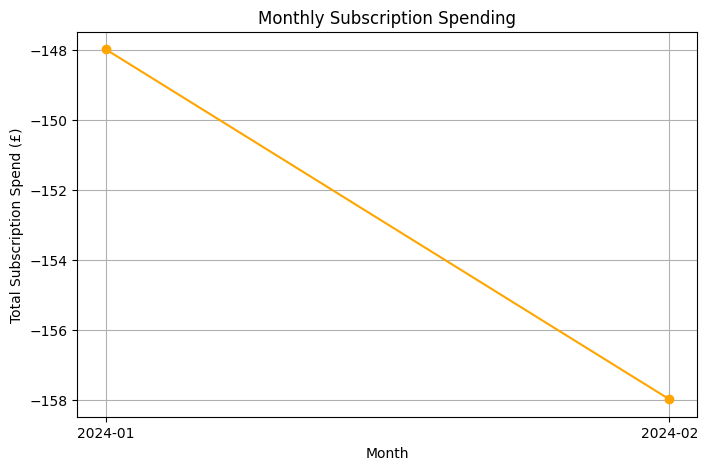

In [ ]:
# Line chart showing how subscription costs change over time
plt.figure(figsize=(8,5))
plt.plot(monthly_subscriptions['month'].astype(str), monthly_subscriptions['amount'], marker='o', color='orange')
plt.title("Monthly Subscription Spending")
plt.xlabel("Month")
plt.ylabel("Total Subscription Spend (£)")
plt.grid(True)
plt.show()


In [13]:
active_subscriptions = subscriptions['merchant'].nunique()
active_subscriptions


3

In [14]:
subscription_breakdown = subscriptions.groupby('merchant')['amount'].sum().sort_values()
subscription_breakdown


merchant
BT        -250.00
Spotify    -30.00
Netflix    -25.98
Name: amount, dtype: float64